<a href="https://colab.research.google.com/github/bhashyadeep123-crypto/csot-ml-astronomy/blob/main/submissions/bhashyadeep123-crypto/week1/week1_starter_my_attempt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Mon Jun  1 20:19:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             27W /   70W |     409MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import matplotlib

print(torch.__version__)
print(torchvision.__version__)
print(matplotlib.__version__)

2.11.0+cu128
0.26.0+cu128
3.10.0


In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
Tesla T4


In [ ]:
def device():
  device="cuda" if torch.cuda.is_available() else "cpu"
  return device
a=device()
print(a)



cuda


In [ ]:
import torch
x=torch.randn(3,64,64)
print("shape:",x.shape)
print("Data type:",x.dtype)
print("Device:",x.device)


shape: torch.Size([3, 64, 64])
Data type: torch.float32
Device: cpu


In [ ]:
import torch
x=torch.randn(3,64,64)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Move x to the selected device
x_gpu = x.to(device)
print("Device:", x_gpu.device)
#Verify shape is unchanged
print("Shape:", x_gpu.shape)


Device: cuda:0
Shape: torch.Size([3, 64, 64])


In [ ]:
import torch
x=torch.randn(3,64,64)
x_gpu = x.to(device)
result=x_gpu[0] @ x_gpu[0]
print(result.shape)
print(result.device)


torch.Size([64, 64])
cuda:0


In [ ]:
import time
import torch
size = 4096
n_runs = 5
def bench(device):
    a = torch.randn(size, size, device=device)
    b = torch.randn(size, size, device=device)

    for _ in range(2):
        (a @ b).sum().item()
        if device == "cuda":
          torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        c = a @ b
    if device == "cuda":
        torch.cuda.synchronize()
    t1 = time.perf_counter()
    return (t1 - t0) / n_runs
# CPU benchmark
cpu_time = bench("cpu")
print(f"CPU avg :{cpu_time*1000:.1f} ms")
# GPU benchmark
if torch.cuda.is_available():
    gpu_time = bench("cuda")
    print(f"GPU avg :{gpu_time*1000:.1f} ms")
    speedup = cpu_time / gpu_time
    print(f"Speedup :{speedup:.2f}x")
else:
    print("GPU not available.")



CPU avg :1274.7 ms
GPU avg :43.3 ms
Speedup :29.42x


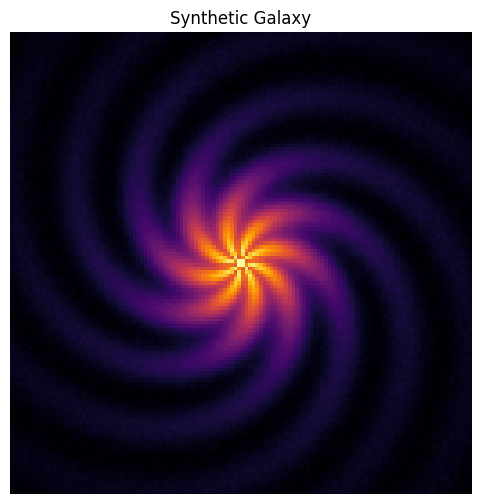

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

N = 128
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Theta = np.arctan2(Y, X)
core = np.exp(-R**2 / 0.08)
arms = (np.cos(4*Theta-10*R)**2* np.exp(-2*R))
galaxy = core + 0.6*arms
galaxy += 0.03*np.random.rand(N, N)
plt.figure(figsize=(6,6))
plt.imshow(galaxy,cmap="inferno")
plt.axis("off")
plt.title("Synthetic Galaxy")
plt.show()

*(1) The most confusing part of setting up Colab, GPU, and PyTorch was making sure that the notebook was actually using the GPU instead of the CPU. I resolved this by enabling the GPU in Runtime → Change runtime type and verifying it with torch.cuda.is_available() and torch.cuda.get_device_name()*.

*(2) For spiral (S) galaxies, a CNN would need to recognize features such as spiral arms, a bright central bulge, and the overall disk structure. The model would learn these patterns from pixel intensities and shapes in the images*.

*(3) We will spend a week on data pipelines because the quality of the input data strongly affects model performance. Proper loading, preprocessing, normalization, augmentation, and batching ensure that the model trains efficiently and learns meaningful patterns rather than noise*.